In [4]:
from PIL import Image
import os

def resize_images(input_folder, size=(224, 224)):
    for filename in os.listdir(input_folder):
        path = os.path.join(input_folder, filename)
        try:
            img = Image.open(path).convert("RGB")
            img = img.resize(size)
            img.save(path)
        except:
            print("Skipped:", filename)

resize_images("banana_dataset/healthy")
resize_images("banana_dataset/unhealthy")

Skipped: (2).DS_Store
Skipped: .DS_Store
Skipped: .DS_Store


In [5]:
import os

healthy_count = len([f for f in os.listdir("banana_dataset/healthy") if not f.startswith(".")])
unhealthy_count = len([f for f in os.listdir("banana_dataset/unhealthy") if not f.startswith(".")])

print("Healthy images:", healthy_count)
print("Unhealthy images:", unhealthy_count)
print("Total images:", healthy_count + unhealthy_count)

Healthy images: 5629
Unhealthy images: 5767
Total images: 11396


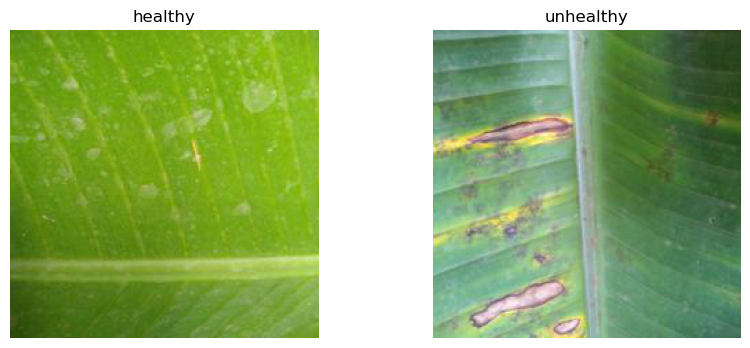

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import random

folders = ["banana_dataset/healthy", "banana_dataset/unhealthy"]

plt.figure(figsize=(10, 4))

for i, folder in enumerate(folders):
    files = [f for f in os.listdir(folder) if not f.startswith(".")]
    sample = random.choice(files)
    img = Image.open(os.path.join(folder, sample))

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.title(folder.split("/")[-1])
    plt.axis("off")

plt.show()

In [ ]:
import os
import shutil
import random

def split_data(source, train_dir, test_dir, split_ratio=0.8):
    files = [f for f in os.listdir(source) if not f.startswith(".")]
    random.shuffle(files)

    split_idx = int(len(files) * split_ratio)
    train_files = files[:split_idx]
    test_files = files[split_idx:]

    for f in train_files:
        shutil.copy(os.path.join(source, f), os.path.join(train_dir, f))

    for f in test_files:
        shutil.copy(os.path.join(source, f), os.path.join(test_dir, f))


# Create folders
os.makedirs("banana_split/train/healthy", exist_ok=True)
os.makedirs("banana_split/train/unhealthy", exist_ok=True)
os.makedirs("banana_split/test/healthy", exist_ok=True)
os.makedirs("banana_split/test/unhealthy", exist_ok=True)

# Split data
split_data("banana_dataset/healthy", "banana_split/train/healthy", "banana_split/test/healthy")
split_data("banana_dataset/unhealthy", "banana_split/train/unhealthy", "banana_split/test/unhealthy")
